In [1]:
import numpy as np
import matplotlib.pyplot as plt

X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')

X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')

X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_test: (76894, 200, 9) y_test: (76894, 2)


In [2]:
import numpy as np

def wrap_angle(angle):
    """
    Wrap angle to [-pi, pi]
    """
    return (angle + np.pi) % (2 * np.pi) - np.pi


def sincos_to_angle(y):
    """
    Convert [sin(theta), cos(theta)] to theta in radians
    """
    return np.arctan2(y[:, 0], y[:, 1])


def circular_mae_deg(pred_deg, true_deg):
    diff = np.abs(pred_deg - true_deg)
    diff = np.minimum(diff, 360 - diff)
    return np.mean(diff)


def circular_rmse_deg(pred_deg, true_deg):
    diff = np.abs(pred_deg - true_deg)
    diff = np.minimum(diff, 360 - diff)
    return np.sqrt(np.mean(diff ** 2))


def magnetometer_heading(window):
    """
    Compute heading from magnetometer x and y.
    Assumes columns:
    0:3 accelerometer
    3:6 gyroscope
    6:9 magnetometer
    """
    mag_x = window[:, 6]
    mag_y = window[:, 7]
    
    # heading at each timestep from magnetometer
    headings = np.arctan2(mag_y, mag_x)
    
    # use circular mean for stability
    sin_mean = np.mean(np.sin(headings))
    cos_mean = np.mean(np.cos(headings))
    
    return np.arctan2(sin_mean, cos_mean)

In [3]:
def ekf_heading_window(window, dt=1/200, Q=0.01, R=0.01):
    """
    EKF for one window of shape (200, 9)
    
    State:
        x = heading angle theta
        
    Prediction:
        theta_k = theta_(k-1) + gyro_z * dt
        
    Measurement:
        z_k = magnetometer heading
        
    Parameters:
        Q = process noise
        R = measurement noise
    """
    gyro_z = window[:, 5]   # gyroscope z-axis
    mag_x = window[:, 6]
    mag_y = window[:, 7]
    
    # initial state from first magnetometer reading
    x = np.arctan2(mag_y[0], mag_x[0])
    P = 1.0
    
    for t in range(len(window)):
        # -------------------
        # 1. Prediction step
        # -------------------
        x_pred = x + gyro_z[t] * dt
        x_pred = wrap_angle(x_pred)
        
        P_pred = P + Q
        
        # -------------------
        # 2. Measurement step
        # -------------------
        z = magnetometer_heading(window)
        z = wrap_angle(z)
        
        # Nonlinear measurement model: h(x)=x
        # Jacobian H = 1
        H = 1.0
        
        # innovation
        y = wrap_angle(z - x_pred)
        
        # innovation covariance
        S = H * P_pred * H + R
        
        # Kalman gain
        K = P_pred * H / S
        
        # state update
        x = x_pred + K * y
        x = wrap_angle(x)
        
        # covariance update
        P = (1 - K * H) * P_pred
    
    return x

In [4]:
# quick test on small subset
n_small = 2000

pred_val_small = np.array([ekf_heading_window(X_val[i]) for i in range(n_small)])
true_val_small = sincos_to_angle(y_val[:n_small])

pred_val_small_deg = np.degrees(pred_val_small)
true_val_small_deg = np.degrees(true_val_small)

mae_small = circular_mae_deg(pred_val_small_deg, true_val_small_deg)
rmse_small = circular_rmse_deg(pred_val_small_deg, true_val_small_deg)

print("Small validation MAE:", mae_small)
print("Small validation RMSE:", rmse_small)

Small validation MAE: 97.02471084126242
Small validation RMSE: 112.05300064380971


In [5]:
pred_val = np.array([ekf_heading_window(X_val[i]) for i in range(len(X_val))])
true_val = sincos_to_angle(y_val)

pred_val_deg = np.degrees(pred_val)
true_val_deg = np.degrees(true_val)

val_mae = circular_mae_deg(pred_val_deg, true_val_deg)
val_rmse = circular_rmse_deg(pred_val_deg, true_val_deg)

print("Validation MAE:", val_mae)
print("Validation RMSE:", val_rmse)

Validation MAE: 86.00334317652106
Validation RMSE: 101.24275883600683


In [6]:
pred_test = np.array([ekf_heading_window(X_test[i]) for i in range(len(X_test))])
true_test = sincos_to_angle(y_test)

pred_test_deg = np.degrees(pred_test)
true_test_deg = np.degrees(true_test)

test_mae = circular_mae_deg(pred_test_deg, true_test_deg)
test_rmse = circular_rmse_deg(pred_test_deg, true_test_deg)

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)

Test MAE: 86.70339273432066
Test RMSE: 102.11288314505869


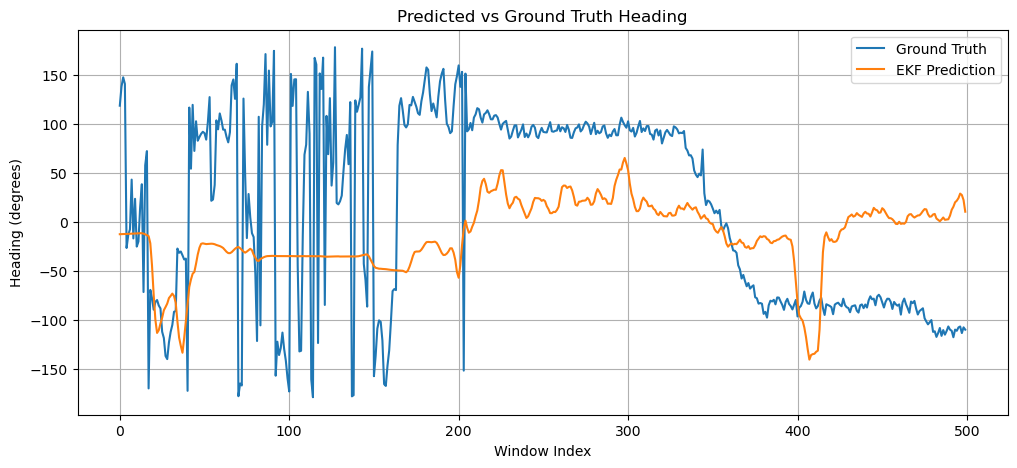

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(true_test_deg[:500], label='Ground Truth')
plt.plot(pred_test_deg[:500], label='EKF Prediction')
plt.xlabel('Window Index')
plt.ylabel('Heading (degrees)')
plt.title('Predicted vs Ground Truth Heading')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
Q_values = [0.0001, 0.001, 0.01]
R_values = [0.01, 0.05, 0.1, 0.5]

best_mae = float('inf')
best_params = None

# use subset first for speed
n_tune = 3000
X_val_tune = X_val[:n_tune]
y_val_tune = y_val[:n_tune]
true_val_tune = sincos_to_angle(y_val_tune)
true_val_tune_deg = np.degrees(true_val_tune)

for Q in Q_values:
    for R in R_values:
        preds = np.array([ekf_heading_window(X_val_tune[i], Q=Q, R=R) for i in range(len(X_val_tune))])
        preds_deg = np.degrees(preds)
        mae = circular_mae_deg(preds_deg, true_val_tune_deg)
        
        print(f"Q={Q}, R={R}, MAE={mae:.4f}")
        
        if mae < best_mae:
            best_mae = mae
            best_params = (Q, R)

print("Best params:", best_params)
print("Best validation MAE:", best_mae)

Q=0.0001, R=0.01, MAE=95.3951
Q=0.0001, R=0.05, MAE=95.3591
Q=0.0001, R=0.1, MAE=95.3533
Q=0.0001, R=0.5, MAE=95.3731
Q=0.001, R=0.01, MAE=95.4037
Q=0.001, R=0.05, MAE=95.4049
Q=0.001, R=0.1, MAE=95.3951
Q=0.001, R=0.5, MAE=95.3591
Q=0.01, R=0.01, MAE=95.3970
Q=0.01, R=0.05, MAE=95.4014
Q=0.01, R=0.1, MAE=95.4037
Q=0.01, R=0.5, MAE=95.4049
Best params: (0.0001, 0.1)
Best validation MAE: 95.35327547349716


In [9]:
best_Q, best_R = best_params

pred_test = np.array([
    ekf_heading_window(X_test[i], Q=best_Q, R=best_R)
    for i in range(len(X_test))
])

true_test = sincos_to_angle(y_test)

pred_test_deg = np.degrees(pred_test)
true_test_deg = np.degrees(true_test)

test_mae = circular_mae_deg(pred_test_deg, true_test_deg)
test_rmse = circular_rmse_deg(pred_test_deg, true_test_deg)

print("Final Test MAE:", test_mae)
print("Final Test RMSE:", test_rmse)

Final Test MAE: 86.76998678256503
Final Test RMSE: 102.16692614382501
